In [12]:
import sys
sys.path.insert(0, '..')
from dependencies import *

envelopes_log = eelbrain.load.unpickle(PROCESSED_PREDICTOR_DIR / f'~processed_envelopes-log.pickle')
durations = get_durations(envelopes_log)
models = get_models(exclude=['envelope_log_8band'])
subject_model_predictors = eelbrain.load.unpickle(PREDICTOR_DIR / f'~concatenated_predictors.pickle')



===== Subject S13 =====

Model: envelope_log
r = 0.3866, r² = 0.1495


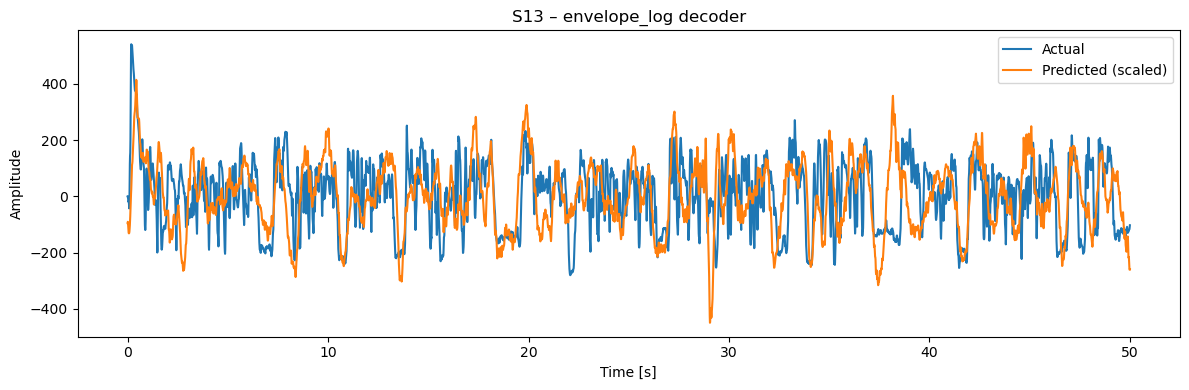

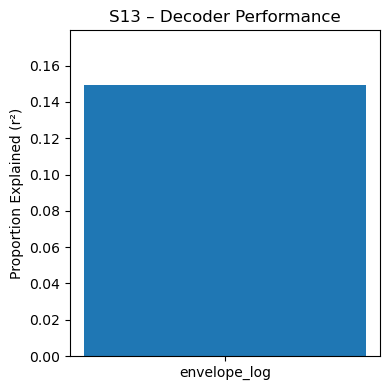


Model: envelope_onset
r = 0.1476, r² = 0.0218


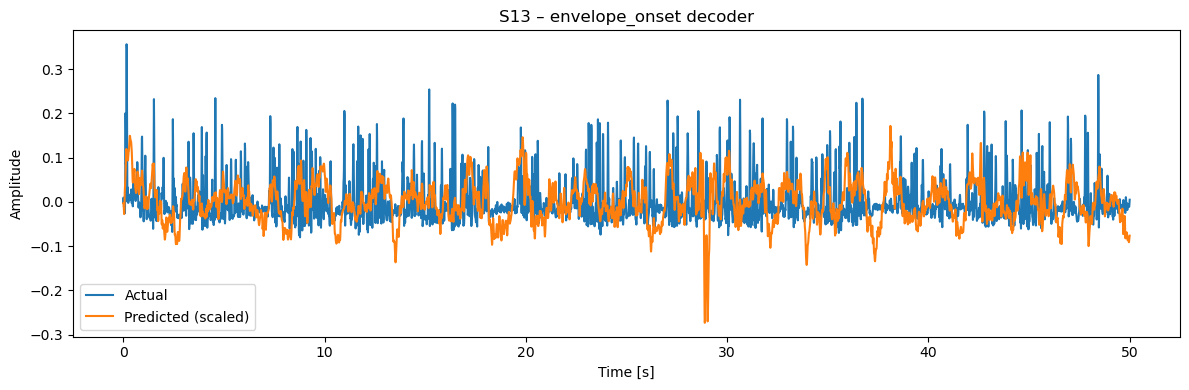

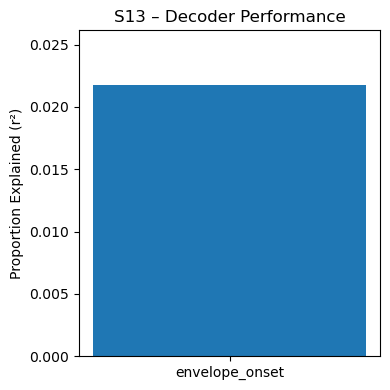


Model: envelope_log_onset
r = 0.3866, r² = 0.1495


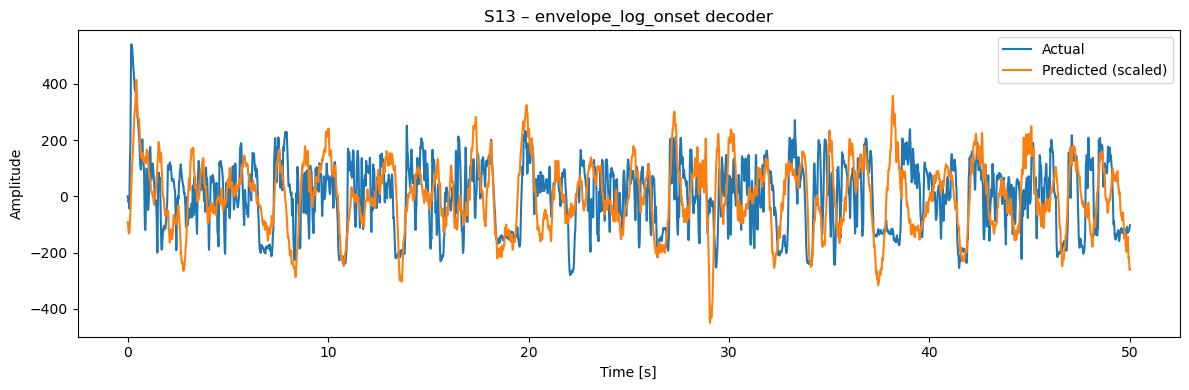

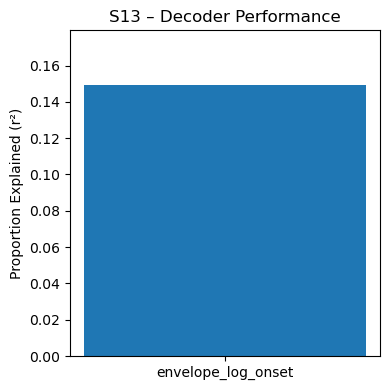


===== Subject S14 =====

Model: envelope_log
r = 0.3014, r² = 0.0908


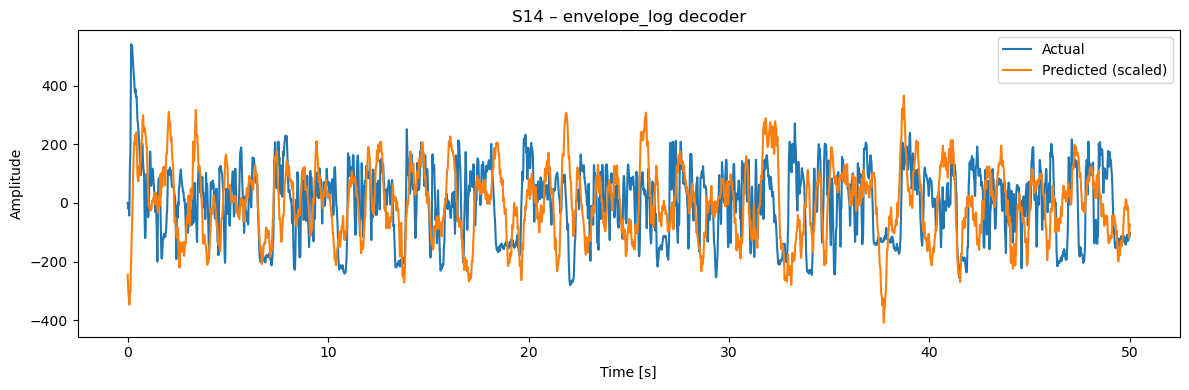

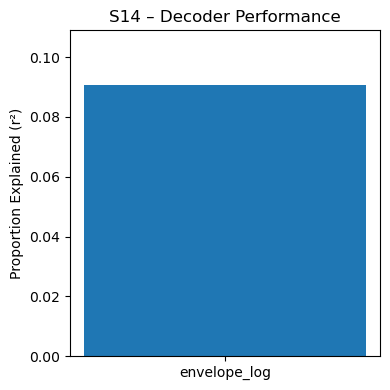


Model: envelope_onset
r = 0.1043, r² = 0.0109


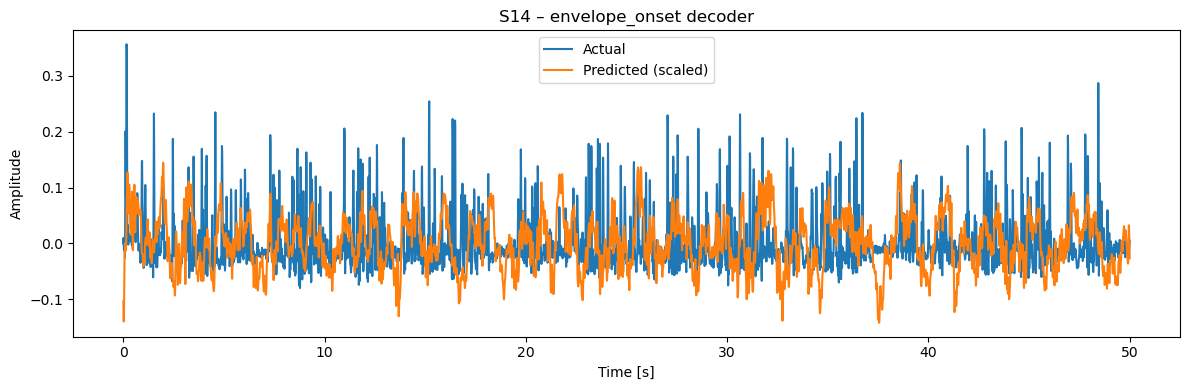

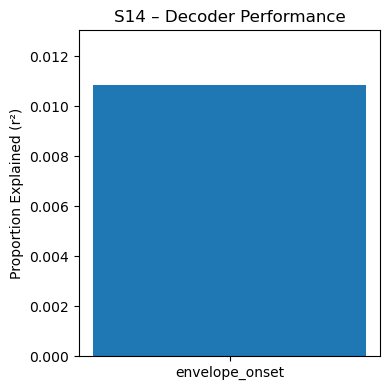


Model: envelope_log_onset
r = 0.3014, r² = 0.0908


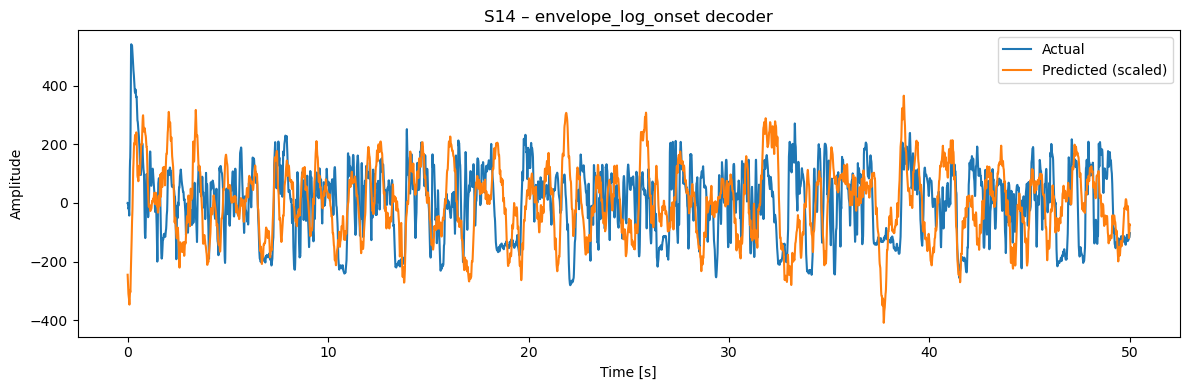

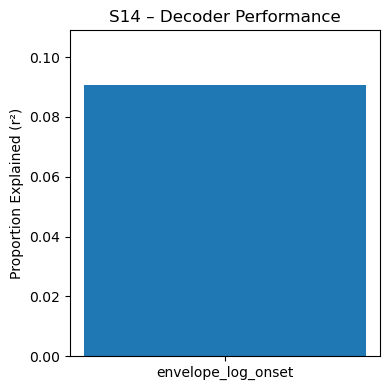


===== Subject S41 =====

Model: envelope_log
r = 0.2518, r² = 0.0634


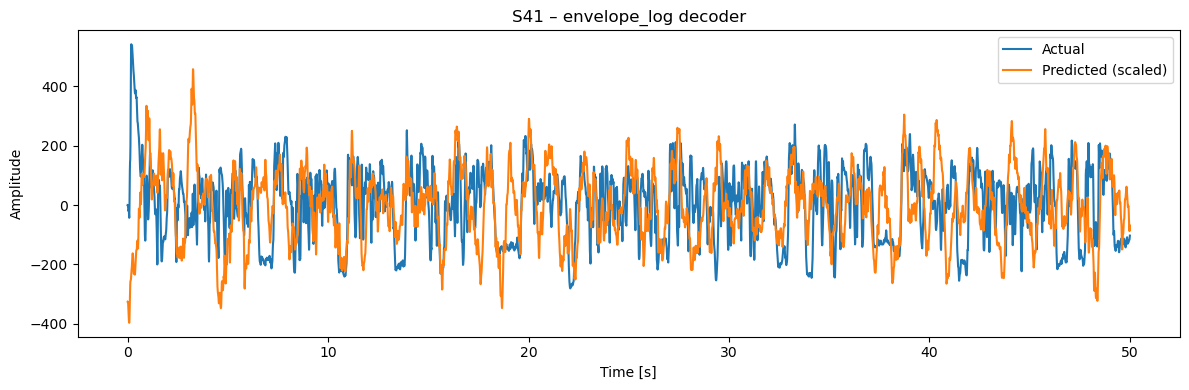

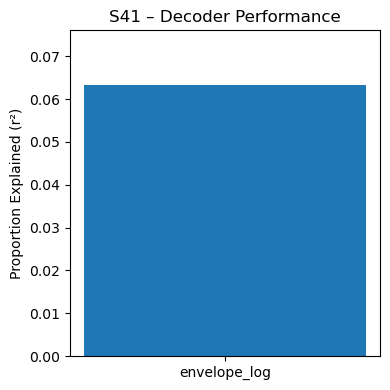


Model: envelope_onset
r = 0.0925, r² = 0.0086


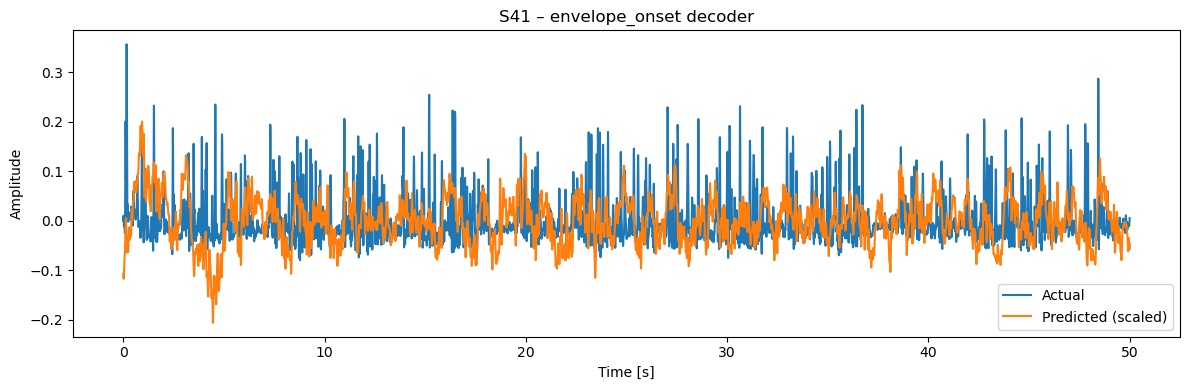

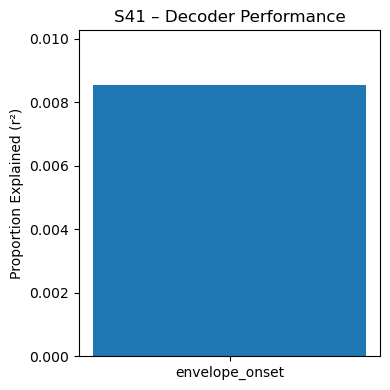


Model: envelope_log_onset
r = 0.2518, r² = 0.0634


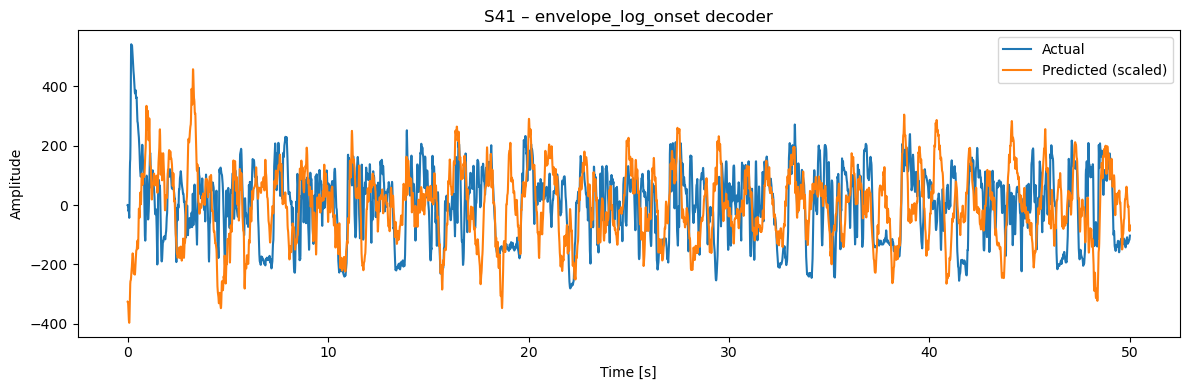

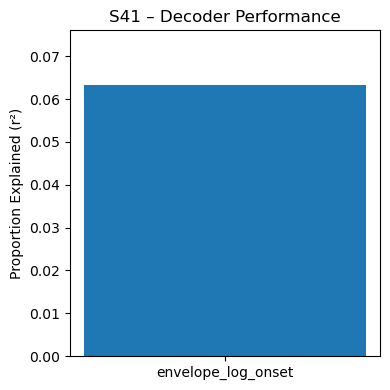

In [15]:
# ------------------------------------------------
# Load predictors and models
# ------------------------------------------------

models = ['envelope_log', 'envelope_onset', 'envelope_log_onset']
subjects = ['S13', 'S14', 'S41']

# ------------------------------------------------
# Run decoder evaluation
# ------------------------------------------------

for subject in subjects:

    print(f'\n===== Subject {subject} =====')

    eeg = eelbrain.load.unpickle(STIMULUS_DIR / f'{subject}concatenated_eeg.pickle')

    for model in models:

        print(f'\nModel: {model}')

        # ----------------------------------------
        # Load decoder TRF
        # ----------------------------------------

        trf_decoder = eelbrain.load.unpickle(
            TRF_DIR / subject / f'{subject} decoder-{model}.pickle'
        )

        predictors = subject_model_predictors[subject][model]

        # ----------------------------------------
        # Predict stimulus from EEG
        # ----------------------------------------

        predicted = eelbrain.convolve(trf_decoder.h_scaled, eeg)

        # ----------------------------------------
        # Build actual stimulus (sum if multiple)
        # ----------------------------------------

        if len(predictors) == 1:
            stimulus = predictors[0]
        else:
            stimulus = predictors[0]
            for p in predictors[1:]:
                stimulus = stimulus + p

        # ----------------------------------------
        # Convert to numpy
        # ----------------------------------------

        env = stimulus.x
        pred = predicted.x
        time = stimulus.time.times

        # ----------------------------------------
        # Correlation
        # ----------------------------------------

        r = np.corrcoef(env, pred)[0,1]
        r2 = r**2

        print(f'r = {r:.4f}, r² = {r2:.4f}')

        # ----------------------------------------
        # Restrict to first 50 seconds
        # ----------------------------------------

        t_max = 50
        mask = time <= t_max

        time_50 = time[mask]
        env_50 = env[mask]
        pred_50 = pred[mask]

        # Scale prediction for visualization
        pred_scaled = pred_50 * (env_50.std() / pred_50.std())

        # ----------------------------------------
        # Plot waveform
        # ----------------------------------------

        plt.figure(figsize=(12,4))

        plt.plot(time_50, env_50, label='Actual')
        plt.plot(time_50, pred_scaled, label='Predicted (scaled)')

        plt.title(f'{subject} – {model} decoder')
        plt.xlabel('Time [s]')
        plt.ylabel('Amplitude')

        plt.legend()
        plt.tight_layout()
        plt.show()

        # ----------------------------------------
        # r² bar plot
        # ----------------------------------------

        plt.figure(figsize=(4,4))

        plt.bar([model], [r2])

        plt.ylabel('Proportion Explained (r²)')
        plt.title(f'{subject} – Decoder Performance')

        plt.ylim(0, max(0.001, r2*1.2))

        plt.tight_layout()
        plt.show()

# Predict envelope from eeg data for 8-band

In [4]:
# PREDICT ENVELOPES FROM THE EEG DATA

subject = 'S05'
model = 'envelope_log_8band'
trf_decoder = eelbrain.load.unpickle(TRF_DIR / f'{subject}' / f'{subject} decoder-{model}.pickle')
eeg = eelbrain.load.unpickle(STIMULUS_DIR / f'{subject}concatenated_eeg.pickle')
subject_model_predictor = eelbrain.load.unpickle(PREDICTOR_DIR / f'~concatenated_predictors.pickle')
envelope = subject_model_predictor[subject][model][0]

#print(trf_s05.h_scaled)
#print(envelopes_log)

predicted_envelope = eelbrain.convolve(trf_decoder.h_scaled, eeg)
# Convert NDVars to numpy arrays for plotting
envelope_data = envelope.x             # shape: (frequency, time)
time = envelope.time
#print(predicted_envelope)
#print(envelope_data)

In [5]:
# Extract numpy arrays
env = envelope.x                 # shape: (bands, time)
pred = predicted_envelope.x

n_bands = env.shape[0]

# Compute Pearson r per band
r_values = np.array([
    np.corrcoef(env[i], pred[i])[0, 1]
    for i in range(n_bands)
])

# Compute r²
r_squared_values = r_values ** 2

# Print nicely
for i in range(n_bands):
    print(f"Band {i}: r = {r_values[i]:.4f}, r² = {r_squared_values[i]:.4f}")


Band 0: r = 0.1423, r² = 0.0202
Band 1: r = 0.1680, r² = 0.0282
Band 2: r = 0.1641, r² = 0.0269
Band 3: r = 0.1514, r² = 0.0229
Band 4: r = 0.1500, r² = 0.0225
Band 5: r = 0.1556, r² = 0.0242
Band 6: r = 0.1322, r² = 0.0175
Band 7: r = 0.1163, r² = 0.0135


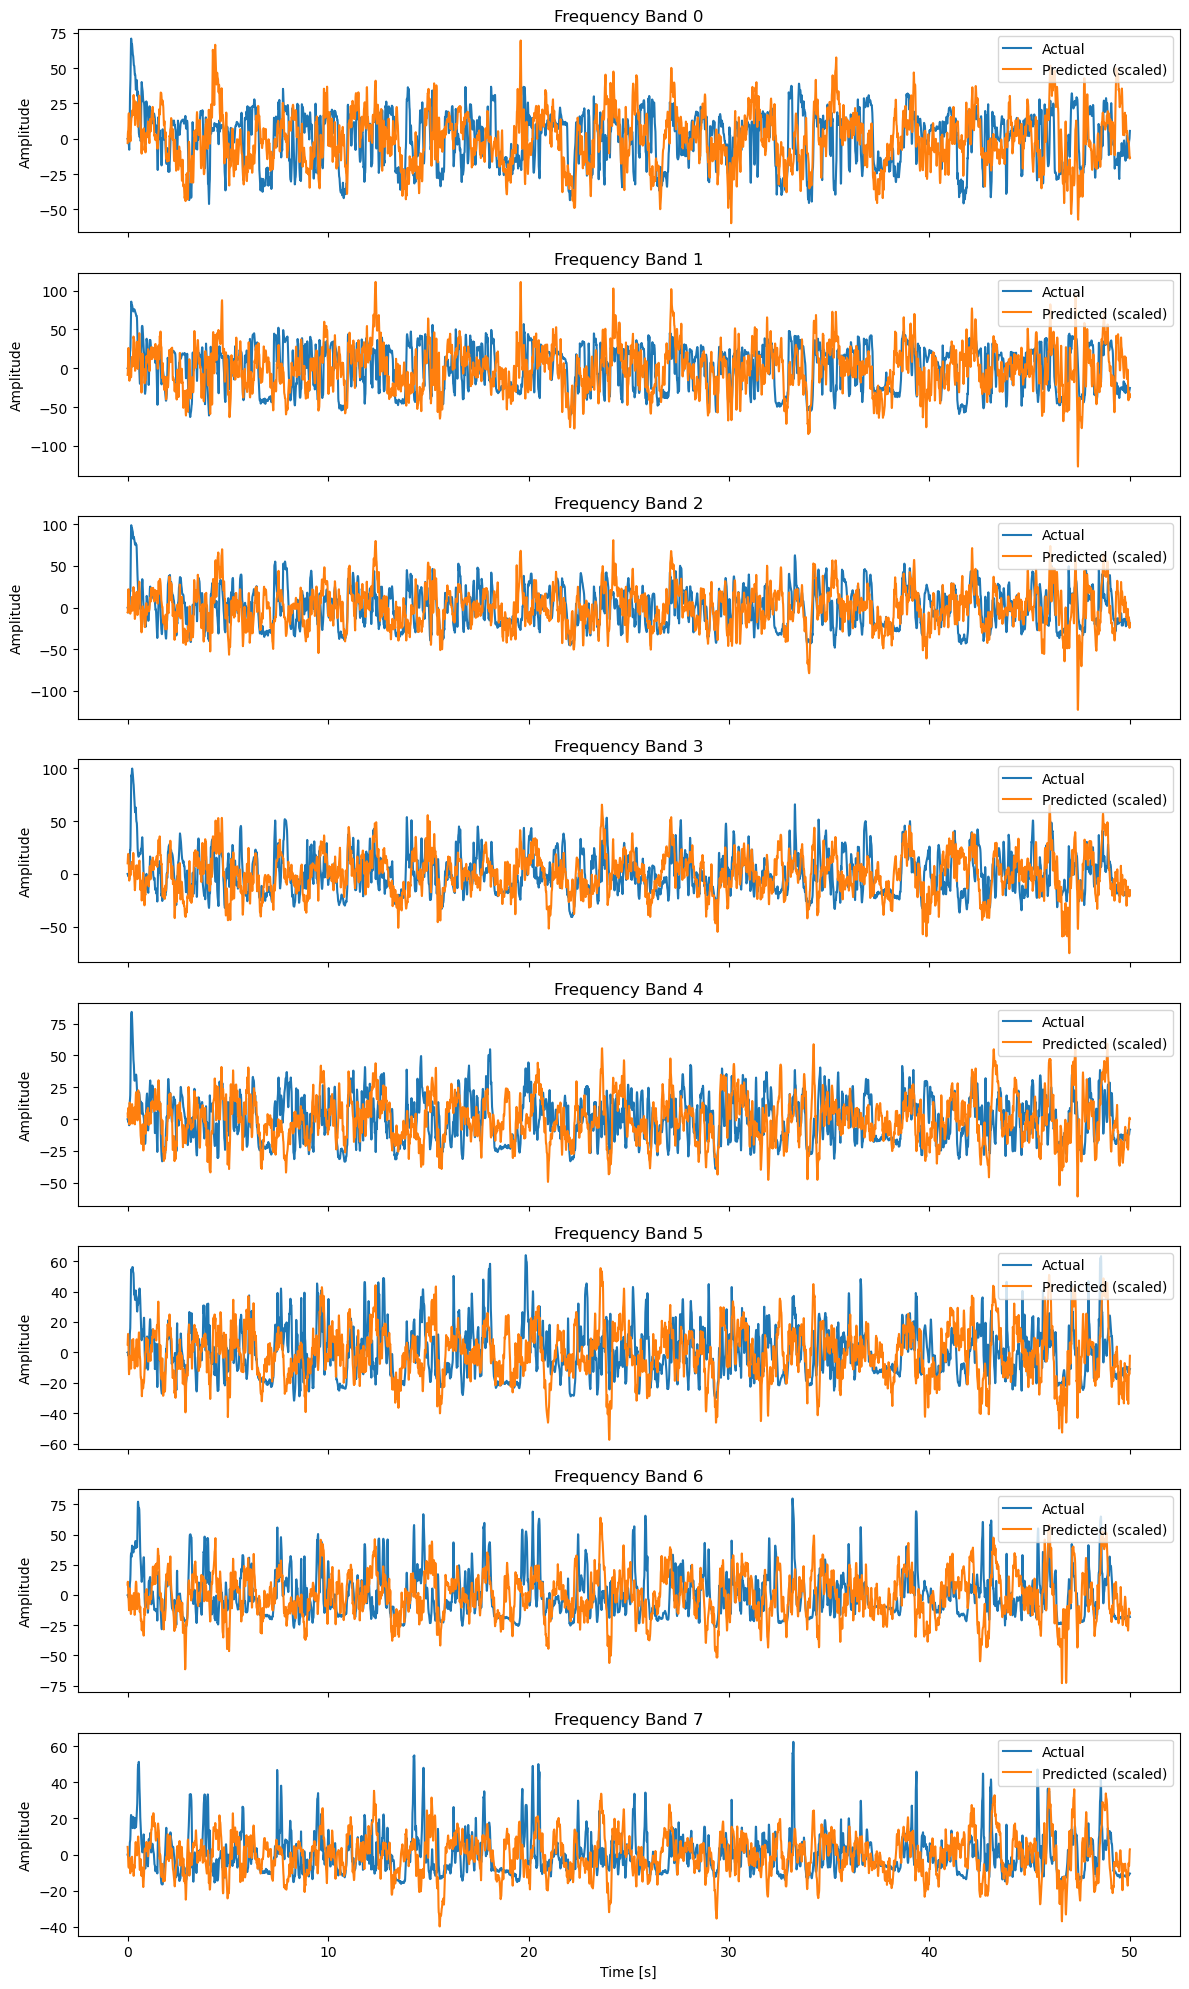

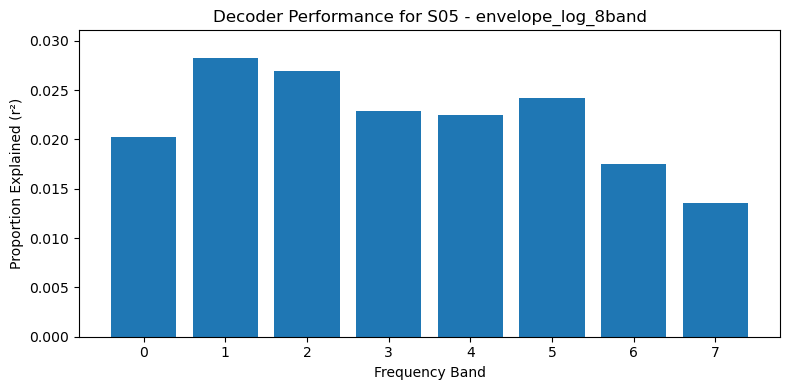

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Extract arrays
env = envelope.x
pred = predicted_envelope.x
time = envelope.time.times   # ← FIXED (extract numeric time values)

n_bands = env.shape[0]

# --------------------------------------------
# Restrict to first 50 seconds
# --------------------------------------------
t_max = 50
time_mask = time <= t_max

time_50 = time[time_mask]
env_50 = env[:, time_mask]
pred_50 = pred[:, time_mask]

# Scale predicted envelope for visualization ONLY
pred_scaled_50 = pred_50 * (env_50.std(axis=1) / pred_50.std(axis=1))[:, None]
#pred_scaled_50 = pred_50

# --------------------------------------------
# Plot each band in its own subplot
# --------------------------------------------
fig, axes = plt.subplots(n_bands, 1, figsize=(12, 2.5*n_bands), sharex=True)

for i in range(n_bands):
    ax = axes[i]
    ax.plot(time_50, env_50[i], label='Actual')
    ax.plot(time_50, pred_scaled_50[i], label='Predicted (scaled)')
    ax.set_ylabel('Amplitude')
    ax.set_title(f'Frequency Band {i}')
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Time [s]')
plt.tight_layout()
plt.show()


# --------------------------------------------
# Bar plot of r² (computed on full data)
# --------------------------------------------
plt.figure(figsize=(8, 4))
plt.bar(range(n_bands), r_squared_values)
plt.xlabel('Frequency Band')
plt.ylabel('Proportion Explained (r²)')
plt.title(f'Decoder Performance for {subject} - {model}')
plt.xticks(range(n_bands))
plt.ylim(0, max(r_squared_values)*1.1)
plt.tight_layout()
plt.show()



# Universal Decoder trf